# Exploring the Instance Space model

A trained Instance Space model can be used to analyse unseen instances: project them into the
two-dimensional instance space, predict which algorithms will perform well on them, and check
whether they fall inside the trained performance footprints. That is what `explore()` does, and
this notebook walks through it step by step.

`explore()` applies a model trained by `build()` to new instances and re-fits nothing — it only
reuses the parameters learned at training time.

Run this notebook from the repository root.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import MultiPolygon

from instancespace.data.metadata import from_csv_file
from instancespace.data.options import InstanceSpaceOptions
from instancespace.instance_space import InstanceSpace

INPUT_DIR = Path("tests/matlab_reference/input")

## Training a model to explore

`explore()` needs a trained model. In practice you either load one you saved earlier or train one
with `build()`. Here we build it once on the trial training set. Training runs the full pipeline
and takes a few minutes, so its progress log is suppressed below.

In [2]:
import contextlib
import io
import time

from loguru import logger

train = from_csv_file(INPUT_DIR / "metadata.csv")
options = InstanceSpaceOptions.default(*([None] * 12))
space = InstanceSpace(train, options)

t0 = time.time()
logger.disable("instancespace")
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    space.build()
logger.enable("instancespace")
print(f"model trained in {time.time() - t0:.0f}s")

model trained in 315s


## Setting up the test data

The test set uses the same metadata format as training: an `Instances` identifier column and
`feature_` columns (any `algo_` performance columns are optional and unused at inference). Load it
with `from_csv_file`.

In [3]:
test_metadata = from_csv_file(INPUT_DIR / "metadata_test.csv")
print(f"{len(test_metadata.instance_labels)} test instances, "
      f"{len(test_metadata.feature_names)} features")

235 test instances, 10 features


## The one call: `explore()`

To apply the model to the test instances you call `explore()` once. It runs every stage — PRELIM
scaling, SIFTED feature selection, the PILOT projection, the PYTHIA selectors and the TRACE
footprints — using the stored parameters, and returns an `ExploreResult` with the projected
coordinates, the per-algorithm predictions and the footprint membership. Nothing is re-fitted.

The log line below is `explore()` reporting that it detected a Python-built model and converted it
internally; the fitted scikit-learn model stays available on `space.model`.

In [4]:
result = space.explore(test_metadata)
print(f"z {result.z.shape}, y_hat {result.y_hat.shape}, "
      f"in_good {result.in_good.shape}, in_best {result.in_best.shape}")

2026-07-21 17:12:52.189 | INFO     | instancespace.instance_space:_ensure_explore_model:455 - explore(): detected a Python-built model (scikit-learn SVMs); converting it to the flattened structure explore() consumes. The unconverted scikit-learn model remains available via the 'model' property.


z (235, 2), y_hat (235, 10), in_good (235, 10), in_best (235, 10)


## Inspecting it one stage at a time

`explore()` returns everything at once. When you want to see what each stage produces — to
understand the pipeline, or to check where a result comes from — `explore_iter()` runs the same
computation but yields each stage's output as it is produced: `prelim`, `sifted`, `pilot`,
`pythia`, `trace`. The sections below use it to look at the projection, the predictions and the
footprints in turn.

In [5]:
stages = {}
for stage, output in space.explore_iter(test_metadata):
    if isinstance(output, tuple):
        desc = ", ".join(str(np.asarray(o).shape) for o in output)
    else:
        desc = str(output.shape)
    print(f"{stage:7} -> {desc}")
    stages[stage] = output

prelim  -> (235, 10)
sifted  -> (235, 6)
pilot   -> (235, 2)
pythia  -> (235, 10), (235, 10), (235,)
trace   -> (235, 10), (235, 10)


### Projecting the data

PILOT projects each instance from feature space into the two-dimensional instance space (a single
matrix product with the trained projection matrix). Below, the test instances are drawn over the
training instances (grey) that define the space.

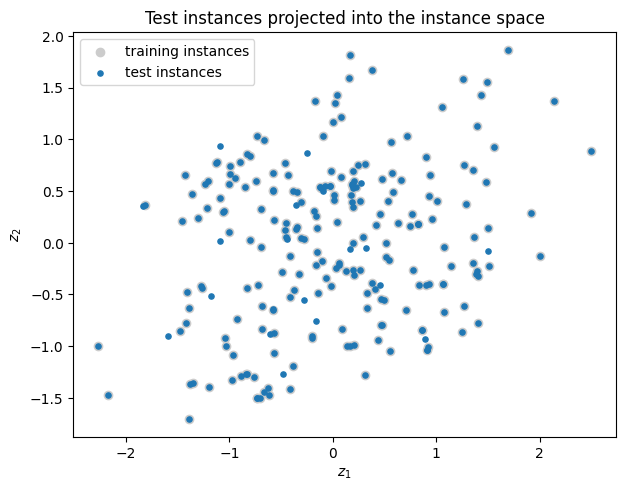

In [6]:
z = stages["pilot"]
z_train = np.asarray(space.model.pilot.z)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(z_train[:, 0], z_train[:, 1], c="0.8", s=36, label="training instances")
ax.scatter(z[:, 0], z[:, 1], c="tab:blue", s=14, label="test instances")
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$")
ax.set_title("Test instances projected into the instance space")
ax.legend(loc="upper left")
ax.set_aspect("equal")
plt.show()

### Testing PYTHIA

For each algorithm, PYTHIA predicts whether it will perform well on an instance, and recommends the
algorithm with the highest precision-weighted confidence. Below, the test instances are coloured by
PYTHIA's good/bad prediction for one algorithm.

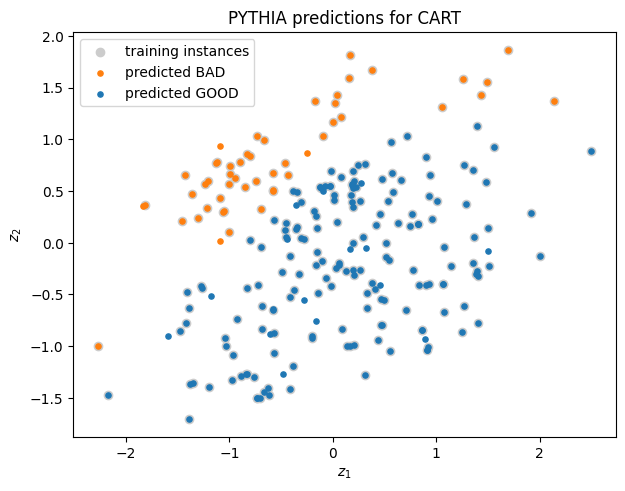

In [7]:
y_hat, pr0_hat, selection0 = stages["pythia"]
algo_labels = [a.replace("algo_", "") for a in space.model.data.algo_labels]

algo = "CART" if "CART" in algo_labels else algo_labels[0]
j = algo_labels.index(algo)
good = y_hat[:, j]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(z_train[:, 0], z_train[:, 1], c="0.8", s=36, label="training instances")
ax.scatter(z[~good, 0], z[~good, 1], c="tab:orange", s=14, label="predicted BAD")
ax.scatter(z[good, 0], z[good, 1], c="tab:blue", s=14, label="predicted GOOD")
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$")
ax.set_title(f"PYTHIA predictions for {algo}")
ax.legend(loc="upper left")
ax.set_aspect("equal")
plt.show()

### Testing the footprints

TRACE records, for each algorithm, the region of the instance space where good performance was
statistically inferred at training time — its *footprint*. At inference each instance is checked
for membership in that region. Below, one algorithm's good footprint is drawn together with the
test instances that fall inside it.

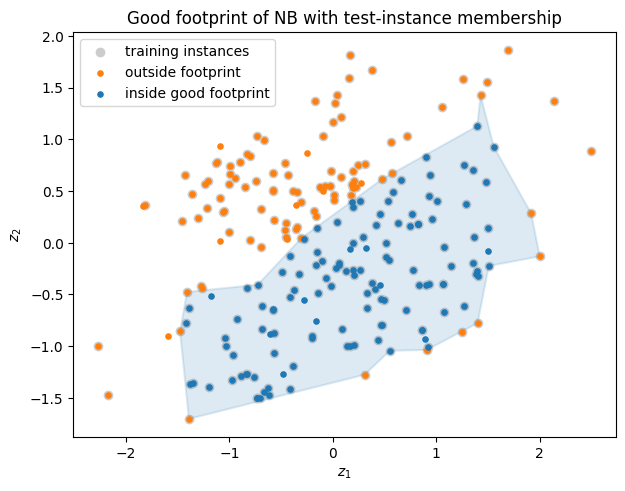

In [8]:
in_good, in_best = stages["trace"]

# pick an algorithm that has a non-empty good footprint
j = next(i for i, fp in enumerate(space.model.trace.good) if fp.polygon is not None)
algo = algo_labels[j]
footprint = space.model.trace.good[j].polygon
inside = in_good[:, j]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(z_train[:, 0], z_train[:, 1], c="0.8", s=36, label="training instances")
regions = footprint.geoms if isinstance(footprint, MultiPolygon) else [footprint]
for region in regions:
    xs, ys = region.exterior.xy
    ax.fill(xs, ys, facecolor="tab:blue", alpha=0.15, edgecolor="tab:blue", linewidth=1.5)
ax.scatter(z[~inside, 0], z[~inside, 1], c="tab:orange", s=14, label="outside footprint")
ax.scatter(z[inside, 0], z[inside, 1], c="tab:blue", s=14, label="inside good footprint")
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$")
ax.set_title(f"Good footprint of {algo} with test-instance membership")
ax.legend(loc="upper left")
ax.set_aspect("equal")
plt.show()

## Using this on your own data

To run this on your own problem, replace the two metadata paths in the setup cells with your own
files (same format as the repository README) and re-run. The whole workflow is just:

```python
space = InstanceSpace(train_metadata, options)
space.build()
result = space.explore(test_metadata)
```

Everything above is that call, opened up stage by stage.